# Model Training and Evaluation: MMP-9 Inhibitors

This notebook executes the final machine learning pipeline for classifying compounds as active or inactive against the MMP-9 target. 

**Workflow Overview:**
1. **Data Loading:** Import the preprocessed, SMOTE-balanced Morgan Fingerprints.
2. **Baseline Establishment:** Train default Random Forest and XGBoost models for comparison.
3. **Champion Model Training:** Train an optimized Random Forest using hyperparameters and a mathematical decision threshold (0.4417) derived from our grid search experiments.
4. **Evaluation:** Visually compare model performance using the Matthews Correlation Coefficient (MCC).
5. **Prediction & Serialization:** Extract the top 20 most confident active compounds and save the model for Virtual Screening.

In [1]:
# --- Numerical and Data Manipulation ---
import numpy as np
import pandas as pd

# --- Visualization Libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Machine Learning Models ---
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

# --- Metrics and Utilities ---
from sklearn.metrics import matthews_corrcoef, confusion_matrix, classification_report
import joblib
import os

print("Libraries imported successfully. Ready for modeling.")

Libraries imported successfully. Ready for modeling.


## 1. Load Model-Ready Data
We load the compressed NumPy archive (`.npz`) generated at the end of the feature engineering pipeline. 
* **Training Data (`X_train`, `y_train`):** Has been balanced using SMOTE to ensure the model learns both active and inactive structural patterns equally.
* **Testing Data (`X_test`, `y_test`):** Was split using Murcko Scaffolds and left untouched by SMOTE to simulate real-world, highly imbalanced chemical data.

In [2]:
# Define the relative path to the processed data directory
data_path = '../data/processed/mmp9_model_ready_splits.npz'

print(f"Loading dataset from: {data_path}...")

# Load the compressed numpy archive
data = np.load(data_path)

# Extract the feature matrices (Morgan Fingerprints) and target labels
X_train, y_train = data['X_train'], data['y_train']
X_test, y_test = data['X_test'], data['y_test']

# Perform a sanity check by printing the shapes of our arrays
print(f"Training Features: {X_train.shape} | Training Labels: {y_train.shape}")
print(f"Testing Features:  {X_test.shape}  | Testing Labels:  {y_test.shape}")

Loading dataset from: ../data/processed/mmp9_model_ready_splits.npz...
Training Features: (2014, 2048) | Training Labels: (2014,)
Testing Features:  (332, 2048)  | Testing Labels:  (332,)


## 2. Train Baseline Models
To prove that our hyperparameter tuning and custom thresholds actually add value, we must first establish a performance baseline. We will train a standard Random Forest and a standard XGBoost classifier using default probability thresholds (0.50).

In [3]:
print("Training Baseline Random Forest...")
# Initialize the baseline RF. We use class_weight='balanced' to handle any residual imbalance.
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced')
rf_base.fit(X_train, y_train)

# Predict using the default 0.5 probability threshold and calculate MCC
# MCC is used because it handles the severe class imbalance in our test set better than accuracy
mcc_rf_base = matthews_corrcoef(y_test, rf_base.predict(X_test))


print("Training Baseline XGBoost...")
# XGBoost requires the scale_pos_weight parameter to handle class imbalance
# It is calculated as the ratio of negative instances to positive instances in the training data
scale_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

xgb_base = xgb.XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=6, 
                             scale_pos_weight=scale_weight, random_state=42, n_jobs=-1)
xgb_base.fit(X_train, y_train)

# Calculate baseline XGBoost MCC
mcc_xgb_base = matthews_corrcoef(y_test, xgb_base.predict(X_test))

print("Baselines trained successfully.")

Training Baseline Random Forest...
Training Baseline XGBoost...
Baselines trained successfully.


## 3. Train the Optimized Champion Model
Based on extensive experimentation, Random Forest outperformed XGBoost on our sparse, 2048-bit Morgan Fingerprint data. 

Furthermore, we determined that adjusting the decision threshold from `0.5000` to `0.4417` mathematically maximized our MCC. This slightly more lenient threshold allows the model to correctly identify hard-to-find active compounds (reducing False Negatives) without suffering a massive increase in False Positives.

In [4]:
print("Training Champion Random Forest...")

# Initialize the model with parameters discovered during RandomizedSearchCV
rf_champ = RandomForestClassifier(
    n_estimators=300,           # More trees for better stability
    min_samples_split=2,        # Default split
    min_samples_leaf=2,         # Requires at least 2 samples per leaf to prevent overfitting
    max_features='sqrt',        # Standard for classification
    max_depth=40,               # Constrains the depth to prevent memorizing the training data
    class_weight='balanced',    # Adjusts weights inversely proportional to class frequencies
    random_state=42, 
    n_jobs=-1                   # Uses all available CPU cores
)

# Fit the champion model to the SMOTE-balanced training data
rf_champ.fit(X_train, y_train)

# --- Apply the Custom Mathematical Threshold ---
optimal_threshold = 0.4417

# 1. Get the raw probability of the compound being 'Active' (Class 1)
y_proba_champ = rf_champ.predict_proba(X_test)[:, 1]

# 2. Apply a boolean mask: If probability >= 0.4417, classify as 1, else 0
y_pred_champ = (y_proba_champ >= optimal_threshold).astype(int)

# Calculate the final, maximized MCC score
mcc_champ = matthews_corrcoef(y_test, y_pred_champ)

# Display the final performance metrics
print("\n--- Champion Model Metrics ---")
print(f"Maximized MCC: {mcc_champ:.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_champ))

Training Champion Random Forest...

--- Champion Model Metrics ---
Maximized MCC: 0.5666
Confusion Matrix:
 [[ 67  45]
 [ 17 203]]


## 4. Performance Comparison
We visualize the MCC scores to clearly communicate how our optimizations improved the model's predictive power compared to the out-of-the-box baselines.

c:\Users\LAPTOP LAB\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


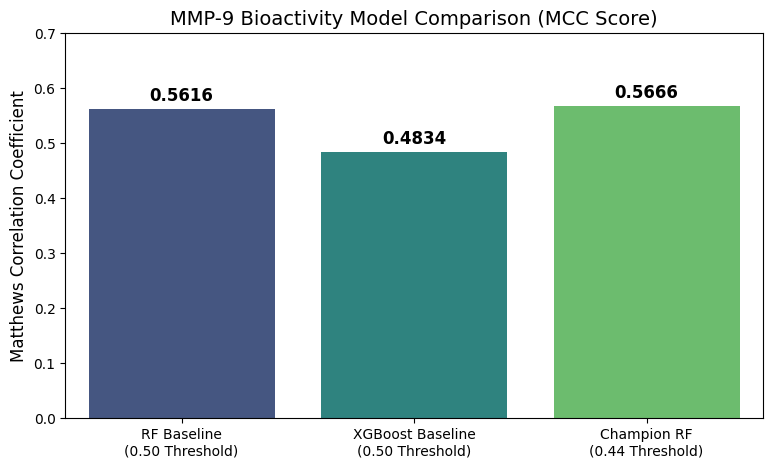

Conclusion: The optimized Random Forest with a 0.4417 threshold safely rescued missing True Actives, yielding the highest MCC.


In [5]:
# Define labels and corresponding scores for the plot
models = ['RF Baseline\n(0.50 Threshold)', 'XGBoost Baseline\n(0.50 Threshold)', 'Champion RF\n(0.44 Threshold)']
mcc_scores = [mcc_rf_base, mcc_xgb_base, mcc_champ]

# Initialize the matplotlib figure
plt.figure(figsize=(9, 5))

# Create a bar plot using seaborn for better aesthetics
ax = sns.barplot(x=models, y=mcc_scores, palette='viridis')

# Add descriptive titles and labels
plt.title('MMP-9 Bioactivity Model Comparison (MCC Score)', fontsize=14)
plt.ylabel('Matthews Correlation Coefficient', fontsize=12)
plt.ylim(0, 0.7) # Set y-axis limit slightly higher than our max score for visual padding

# Iterate through the bars to place the exact text score on top of each bar
for i, v in enumerate(mcc_scores):
    ax.text(i, v + 0.015, f"{v:.4f}", ha='center', fontweight='bold', fontsize=12)

# Render the plot
plt.show()

print("Conclusion: The optimized Random Forest with a 0.4417 threshold safely rescued missing True Actives, yielding the highest MCC.")

## 5. Extract Top High-Confidence Predictions
In drug discovery, we care most about the compounds the model is *absolutely certain* are active. Here, we query the model's probabilities to extract the top 20 most confident active predictions from our unseen test set. We will save this shortlist to a CSV for potential wet-lab review.

In [6]:
# Create a structured DataFrame containing the test indices, true labels, and model probabilities
results_df = pd.DataFrame({
    'Test_Set_Index': np.arange(len(y_test)),
    'True_Bioactivity_Label': y_test,
    'Predicted_Probability': y_proba_champ
})

# Sort the DataFrame by the highest probability in descending order and extract the top 20 rows
top_20_candidates = results_df.sort_values(by='Predicted_Probability', ascending=False).head(20)

print("Top 20 Most Confident 'Active' Predictions from Test Set:")
display(top_20_candidates)

# Save these specific top 20 test results to a CSV file in the processed data folder
output_csv = '../data/processed/top_20_test_predictions.csv'
top_20_candidates.to_csv(output_csv, index=False)

print(f"\nSaved top 20 candidates to {output_csv}")

Top 20 Most Confident 'Active' Predictions from Test Set:


,Test_Set_Index,True_Bioactivity_Label,Predicted_Probability
0,0,1,0.995820
100,100,1,0.995704
113,113,1,0.994225
102,102,1,0.993330
101,101,1,0.991114
111,111,1,0.990370
103,103,1,0.989182
19,19,1,0.987357
105,105,1,0.986121
108,108,1,0.985594



Saved top 20 candidates to ../data/processed/top_20_test_predictions.csv


## 6. Serialize Champion Model
We serialize (save) the trained Random Forest model to disk using `joblib`. 

By saving both the model and a metadata dictionary (which stores our optimal threshold and fingerprint parameters), we can load this exact state in a separate Virtual Screening notebook to evaluate completely novel, unlabelled chemical libraries without needing to retrain the model.

In [7]:
# Define the output directory for serialized models
model_dir = '../models/'

# Ensure the directory exists; if not, create it
os.makedirs(model_dir, exist_ok=True)

# Define exact file paths for the model and its associated metadata
model_path = os.path.join(model_dir, 'mmp9_rf_champion.pkl')
meta_path = os.path.join(model_dir, 'mmp9_rf_metadata.pkl')

# 1. Save the trained sklearn model object
joblib.dump(rf_champ, model_path)

# 2. Create and save a metadata dictionary 
# This ensures we don't forget the custom threshold or feature sizes during deployment
model_metadata = {
    'optimal_threshold': optimal_threshold,
    'n_features': X_train.shape[1],        # Should be 2048 based on Morgan FP radius 2
    'fingerprint_radius': 2,
    'model_type': 'RandomForestClassifier',
    'target': 'MMP-9'
}
joblib.dump(model_metadata, meta_path)

print(f"Success! Model saved to: {model_path}")
print(f"Success! Metadata saved to: {meta_path}")
print("\nPipeline Complete! The model is now ready for Virtual Screening.")

Success! Model saved to: ../models/mmp9_rf_champion.pkl
Success! Metadata saved to: ../models/mmp9_rf_metadata.pkl

Pipeline Complete! The model is now ready for Virtual Screening.
